## Question 1: What is the difference between K-Means and Hierarchical Clustering? Provide a use case for each.

**K-Means Clustering:**
*   **Approach:** K-Means is a **partitioning** clustering algorithm. It aims to partition `n` observations into `k` clusters, where each observation belongs to the cluster with the nearest mean (centroid).
*   **Methodology:** It's an iterative algorithm that starts with an initial set of `k` centroids, assigns each data point to its closest centroid, and then recalculates the centroids based on the mean of the points in each cluster. This process repeats until convergence.
*   **Number of Clusters (k):** Requires the number of clusters (`k`) to be specified beforehand.
*   **Scalability:** Generally more efficient for large datasets due to its linear time complexity.
*   **Shape of Clusters:** Tends to form spherical or convex-shaped clusters.
*   **Sensitivity to Outliers:** Sensitive to outliers, as they can pull the centroids away from the true cluster centers.

**Hierarchical Clustering:**
*   **Approach:** Hierarchical clustering builds a hierarchy of clusters. It can be **agglomerative** (bottom-up, starting with individual data points and merging them into clusters) or **divisive** (top-down, starting with all data points in one cluster and splitting them).
*   **Methodology:**
    *   **Agglomerative:** Starts with each data point as its own cluster. It then iteratively merges the two closest clusters until only one cluster (or `k` clusters) remains. The distance between clusters can be defined in various ways (e.g., single-link, complete-link, average-link, Ward's method).
    *   **Divisive:** Starts with all data points in one cluster and recursively splits them into smaller clusters until each data point is in its own cluster.
*   **Number of Clusters (k):** Does not require `k` to be specified beforehand; `k` can be chosen by cutting the dendrogram at an appropriate level.
*   **Scalability:** Less efficient for very large datasets, as its complexity is typically `O(n^3)` or `O(n^2 log n)` depending on the linkage method.
*   **Shape of Clusters:** Can discover clusters of arbitrary shapes.
*   **Sensitivity to Outliers:** Less sensitive to individual outliers compared to K-Means, but chaining effects can occur with single-linkage.

---

**Use Cases:**

*   **K-Means Use Case:** **Customer Segmentation** for an e-commerce company. The marketing team wants to group customers based on their purchase history (e.g., total spending, frequency of purchases, product categories). K-Means is suitable here because the clusters are likely to be somewhat spherical (e.g.,

## Question 2: Explain the purpose of the Silhouette Score in evaluating clustering algorithms.

**Purpose of the Silhouette Score:**

The Silhouette Score is a metric used to evaluate the quality of clusters created by a clustering algorithm. It quantifies how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to +1, where:

*   **+1:** Indicates that the object is well-matched to its own cluster and poorly matched to neighboring clusters. This suggests a good clustering result where clusters are dense and well-separated.
*   **0:** Indicates that the object is on or very close to the decision boundary between two neighboring clusters. This suggests overlapping clusters.
*   **-1:** Indicates that the object is likely assigned to the wrong cluster, as it is more similar to a neighboring cluster than to its own.

**How it's Calculated:**
For each data point `i`:
1.  **`a(i)` (average intra-cluster distance):** The average distance between `i` and all other data points in the *same cluster*.
2.  **`b(i)` (minimum average inter-cluster distance):** The minimum average distance between `i` and all data points in any *other cluster* (i.e., the closest neighboring cluster).

The Silhouette Score for a single data point `i` is then calculated as:

`s(i) = (b(i) - a(i)) / max(a(i), b(i))`

**Overall Silhouette Score:**

The overall Silhouette Score for a clustering solution is the average `s(i)` over all data points. A higher average Silhouette Score generally indicates better-defined and more separated clusters.

**Key Benefits:**

*   **Evaluates both cohesion and separation:** It considers both how tightly grouped points within a cluster are and how distinct clusters are from each other.
*   **No ground truth needed:** Unlike supervised learning metrics, it does not require prior knowledge of the true labels.
*   **Helps determine optimal `k`:** When comparing clustering solutions with different numbers of clusters (`k` in K-Means), the `k` value that yields the highest Silhouette Score is often considered the optimal number of clusters.

## Question 3: What are the core parameters of DBSCAN, and how do they influence the clustering process?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that can discover arbitrarily shaped clusters and identify noise points. Its core parameters are `eps` (epsilon) and `min_samples`.

### 1. `eps` (epsilon or ε)

*   **Definition:** `eps` defines the maximum radius of the neighborhood around a data point `p`. It determines how close points must be to each other to be considered part of the same cluster.
*   **Influence on Clustering:**
    *   **Small `eps`:** A smaller `eps` value means that points must be very close to each other to be considered neighbors. This can lead to more clusters (potentially many small ones) and a higher number of noise points, as fewer points will meet the density requirement.
    *   **Large `eps`:** A larger `eps` value means that points can be further apart and still be considered neighbors. This can result in fewer, larger clusters, and may cause multiple distinct clusters to merge into one. It also tends to reduce the number of noise points.
*   **Selection:** Choosing `eps` often involves inspecting a K-distance graph (specifically, the distance to the `min_samples`-th nearest neighbor for each point, sorted in ascending order) and looking for an 'elbow' where the slope changes significantly. This suggests a good threshold for density.

### 2. `min_samples`

*   **Definition:** `min_samples` (or `MinPts`) defines the minimum number of data points required to form a dense region (a cluster). It's the minimum number of points (including the point itself) that must be within the `eps` radius of a **core point** for that point to be considered a core point.
*   **Influence on Clustering:**
    *   **Small `min_samples`:** A smaller `min_samples` value makes the density requirement looser. This can lead to more clusters, including smaller and potentially less significant clusters. It also makes the algorithm more sensitive to noise, as even small fluctuations in density might be interpreted as clusters.
    *   **Large `min_samples`:** A larger `min_samples` value makes the density requirement stricter. This tends to produce fewer, more robust clusters, and labels more points as noise (outliers). It helps in filtering out insignificant clusters.
*   **Selection:** A common heuristic is to set `min_samples` to `2 * dimensions` of the dataset, or a value between 3 and 5 for 2D data, but it often requires experimentation.

### How They Work Together:

*   A point `p` is a **core point** if there are at least `min_samples` points (including `p` itself) within its `eps` neighborhood.
*   A point `q` is a **border point** if it is within the `eps` neighborhood of a core point `p`, but it is not a core point itself (i.e., it has fewer than `min_samples` points in its own `eps` neighborhood).
*   A point `n` is a **noise point** (or outlier) if it is neither a core point nor a border point.

Clusters are formed by core points that are density-reachable (directly or indirectly) from each other, along with their associated border points. The careful selection of `eps` and `min_samples` is crucial for DBSCAN to effectively discover meaningful clusters and distinguish them from noise.

## Question 4: Why is feature scaling important when applying clustering algorithms like K-Means and DBSCAN?

Feature scaling is crucial for many clustering algorithms, especially distance-based ones like K-Means and DBSCAN, for several key reasons:

1.  **Distance Calculation Sensitivity:**
    *   Clustering algorithms like K-Means and DBSCAN rely heavily on distance metrics (e.g., Euclidean distance) to determine similarity between data points. When features have different scales (e.g., one feature ranges from 0 to 100, while another ranges from 0 to 1), the feature with the larger range will disproportionately influence the distance calculation.
    *   **Example:** If 'income' is in dollars (e.g., 20,000 to 100,000) and 'age' is in years (e.g., 20 to 70), a small change in income will contribute far more to the overall distance than a large change in age. This can lead to clusters being formed predominantly based on the feature with the largest scale, rather than reflecting the true underlying relationships between all features.

2.  **Equal Contribution of Features:**
    *   Scaling ensures that all features contribute equally to the distance computation. By bringing all features to a similar scale (e.g., between 0 and 1, or with a mean of 0 and standard deviation of 1), no single feature dominates the clustering process simply because of its larger magnitude.
    *   This allows the algorithm to consider all features fairly when identifying patterns and forming clusters, leading to more meaningful and accurate results.

3.  **Algorithm Convergence (K-Means):**
    *   For K-Means, initialization and convergence can be affected by unscaled data. The centroids might move slowly or oscillate in features with small scales, while being heavily pulled by features with large scales.
    *   Scaling can lead to faster convergence of the K-Means algorithm as the cost function becomes more well-behaved and easier to optimize.

4.  **Density Estimation (DBSCAN):**
    *   DBSCAN relies on the concept of density, which is defined by the `eps` (radius) parameter. If features are not scaled, the `eps` value will have different meanings across different dimensions. For instance, an `eps` of 0.5 might be a significant distance for a scaled feature, but negligible for an unscaled feature with a large range.
    *   Scaling ensures that the `eps` parameter consistently defines the neighborhood density across all dimensions, allowing DBSCAN to accurately identify dense regions and noise.

**Common Scaling Techniques:**

*   **Standardization (Z-score normalization):** Transforms data to have a mean of 0 and a standard deviation of 1. `X_scaled = (X - mean) / std_dev`.
*   **Min-Max Scaling (Normalization):** Transforms data to a fixed range, typically between 0 and 1. `X_scaled = (X - min) / (max - min)`.

In summary, feature scaling is a critical preprocessing step that prevents features with larger numerical ranges from unduly influencing clustering results, ensuring that algorithms like K-Means and DBSCAN can accurately identify inherent data structures based on the true similarity of data points across all relevant features.

## Question 5: What is the Elbow Method in K-Means clustering and how does it help determine the optimal number of clusters?

The **Elbow Method** is a heuristic used to help determine the optimal number of clusters (`k`) for K-Means clustering. It relies on the concept of **Within-Cluster Sum of Squares (WCSS)**, also known as inertia.

### What is WCSS (Inertia)?

WCSS is the sum of the squared distances between each point and the centroid of its assigned cluster. It measures the compactness of the clusters. A smaller WCSS value generally indicates that the points are closer to their respective centroids, meaning the clusters are more compact.

### How the Elbow Method Works:

1.  **Run K-Means for a range of `k` values:** You perform K-Means clustering for a range of possible `k` values (e.g., from 1 to 10 or 15).
2.  **Calculate WCSS for each `k`:** For each `k` value, calculate the WCSS (inertia) after the clustering process has converged.
3.  **Plot WCSS vs. `k`:** Plot the calculated WCSS values against the corresponding `k` values.

### Interpreting the "Elbow":

The plot of WCSS versus `k` typically looks like an arm. As `k` increases, the WCSS will naturally decrease because adding more clusters will always reduce the distance between points and their closest centroids. However, the rate of decrease in WCSS usually slows down at a certain point. This point of inflection, where the curve starts to bend and resemble an "elbow," is considered the optimal `k`.

*   **Before the elbow:** The decrease in WCSS is sharp, meaning that adding another cluster significantly improves the clustering by reducing the sum of squared errors.
*   **At the elbow:** The rate of decrease sharply diminishes. This suggests that adding more clusters beyond this point provides diminishing returns; the gains in compactness are no longer substantial enough to justify the increased complexity of more clusters.
*   **After the elbow:** The WCSS continues to decrease, but very slowly. This indicates that adding more clusters is not significantly improving the clustering structure.

### Limitations:

*   **Subjectivity:** The "elbow" might not always be clear or obvious, making the selection of `k` subjective.
*   **Local Optima:** K-Means can converge to local optima, so running the algorithm multiple times with different initial centroids (and taking the best result) is often necessary.
*   **Cluster Shape:** The method works best for datasets with clear, spherical clusters.

## Question 6: Generate synthetic data using `make_blobs(n_samples=300, centers=4)`, apply KMeans clustering, and visualize the results with cluster centers.

(Include your Python code and output in the code box below.)

Generated 300 samples with 4 true centers.
Shape of data (X): (300, 2)


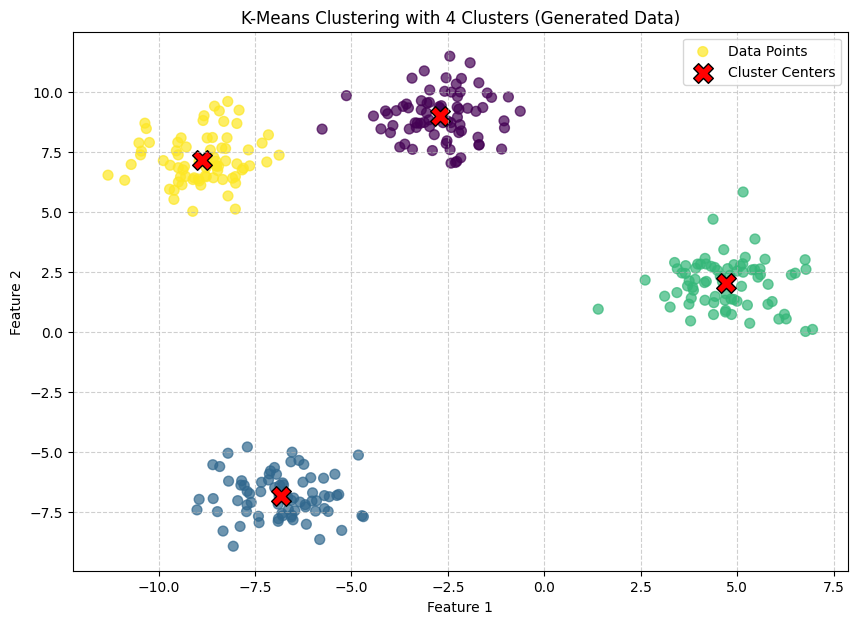

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generate synthetic data
n_samples = 300
n_centers = 4
X, y = make_blobs(n_samples=n_samples, centers=n_centers, random_state=42)

print(f"Generated {n_samples} samples with {n_centers} true centers.")
print(f"Shape of data (X): {X.shape}")

# 2. Apply KMeans clustering
kmeans = KMeans(n_clusters=n_centers, random_state=42, n_init=10) # n_init for robust results
kmeans.fit(X)

# Get cluster labels and centers
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# 3. Visualize the results
plt.figure(figsize=(10, 7))

# Plot data points, colored by cluster label
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis', alpha=0.7, label='Data Points')

# Plot cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', edgecolors='black', label='Cluster Centers')

plt.title(f'K-Means Clustering with {n_centers} Clusters (Generated Data)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Question 7: Load the Wine dataset, apply StandardScaler , and then train a DBSCAN model. Print the number of clusters found (excluding noise).

(Include your Python code and output in the code box below.)

In [2]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# 1. Load the Wine dataset
wine = load_wine()
X_wine = wine.data

print(f"Original Wine dataset shape: {X_wine.shape}")

# 2. Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

print(f"Scaled Wine dataset shape: {X_scaled.shape}")

# 3. Train a DBSCAN model
# DBSCAN parameters often require tuning. For demonstration, we'll pick some values.
# A common strategy for 'eps' involves a k-distance plot, and 'min_samples' is often 2 * n_features or more.
# Let's try some typical values for this dataset, or iterate if needed.
# For the Wine dataset (13 features), min_samples could be around 2*13 = 26, or a smaller number like 5.
# We'll start with values that often work reasonably well for density-based datasets.
eps_value = 1.8 # This value often yields reasonable results for Wine dataset after scaling
min_samples_value = 5 # Standard choice, or 2*n_features (26) could be too strict initially

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
clusters = dbscan.fit_predict(X_scaled)

# 4. Print the number of clusters found (excluding noise)
# Noise points are labeled as -1 by DBSCAN
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print(f"DBSCAN Parameters: eps={eps_value}, min_samples={min_samples_value}")
print(f"Number of clusters found (excluding noise): {n_clusters}")
print(f"Cluster labels: {np.unique(clusters)}")
print(f"Number of noise points: {np.sum(clusters == -1)}")

Original Wine dataset shape: (178, 13)
Scaled Wine dataset shape: (178, 13)
DBSCAN Parameters: eps=1.8, min_samples=5
Number of clusters found (excluding noise): 7
Cluster labels: [-1  0  1  2  3  4  5  6]
Number of noise points: 118


## Question 8: Generate moon-shaped synthetic data using `make_moons(n_samples=200, noise=0.1)`, apply DBSCAN, and highlight the outliers in the plot.

(Include your Python code and output in the code box below.)

Generated 200 moon-shaped samples with noise=0.1.
Shape of data (X_moons): (200, 2)


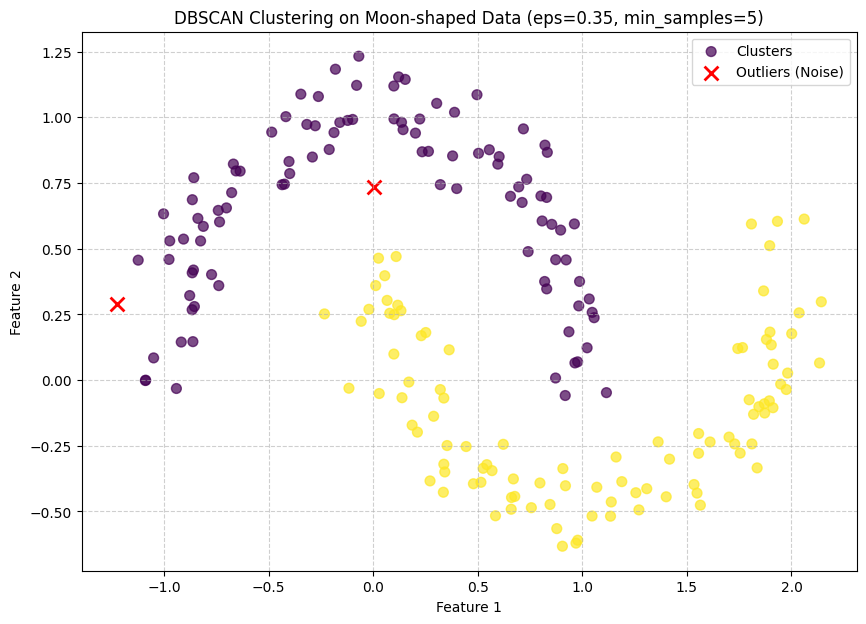

DBSCAN Parameters for moons: eps=0.35, min_samples=5
Number of clusters found (excluding noise) for moons: 2
Number of noise points for moons: 2


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Generate moon-shaped synthetic data
n_samples = 200
noise_level = 0.1
X_moons, y_moons = make_moons(n_samples=n_samples, noise=noise_level, random_state=42)

print(f"Generated {n_samples} moon-shaped samples with noise={noise_level}.")
print(f"Shape of data (X_moons): {X_moons.shape}")

# 2. Apply DBSCAN
# It's good practice to scale data for DBSCAN, especially if features have different ranges.
# Although make_moons usually generates data within a similar range, scaling can still be beneficial.
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

# Tune DBSCAN parameters for moon-shaped data
# For make_moons with noise=0.1, eps around 0.3-0.4 and min_samples=5 often works well.
eps_moons = 0.35 # Adjusted for scaled data and typical make_moons noise
min_samples_moons = 5 # A common choice, or 2*n_features = 4

dbscan_moons = DBSCAN(eps=eps_moons, min_samples=min_samples_moons)
clusters_moons = dbscan_moons.fit_predict(X_moons_scaled)

# Identify outliers (-1 label)
outliers = X_moons[clusters_moons == -1]

# 3. Highlight the outliers in the plot
plt.figure(figsize=(10, 7))

# Plot data points, colored by cluster label
# Use original (unscaled) X for plotting for better interpretability if scaling was applied
plt.scatter(X_moons[clusters_moons != -1, 0],
            X_moons[clusters_moons != -1, 1],
            c=clusters_moons[clusters_moons != -1],
            cmap='viridis', s=50, alpha=0.7,
            label='Clusters')

# Plot outliers
if len(outliers) > 0:
    plt.scatter(outliers[:, 0], outliers[:, 1],
                c='red', marker='x', s=100, linewidths=2,
                label='Outliers (Noise)')

plt.title(f'DBSCAN Clustering on Moon-shaped Data (eps={eps_moons}, min_samples={min_samples_moons})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

n_clusters_moons = len(set(clusters_moons)) - (1 if -1 in clusters_moons else 0)
print(f"DBSCAN Parameters for moons: eps={eps_moons}, min_samples={min_samples_moons}")
print(f"Number of clusters found (excluding noise) for moons: {n_clusters_moons}")
print(f"Number of noise points for moons: {np.sum(clusters_moons == -1)}")

## Question 9: Load the Wine dataset, reduce it to 2D using PCA, then apply Agglomerative Clustering and visualize the result in 2D with a scatter plot.

(Include your Python code and output in the code box below.)

Original Wine dataset shape: (178, 13)
Wine dataset shape after PCA to 2D: (178, 2)


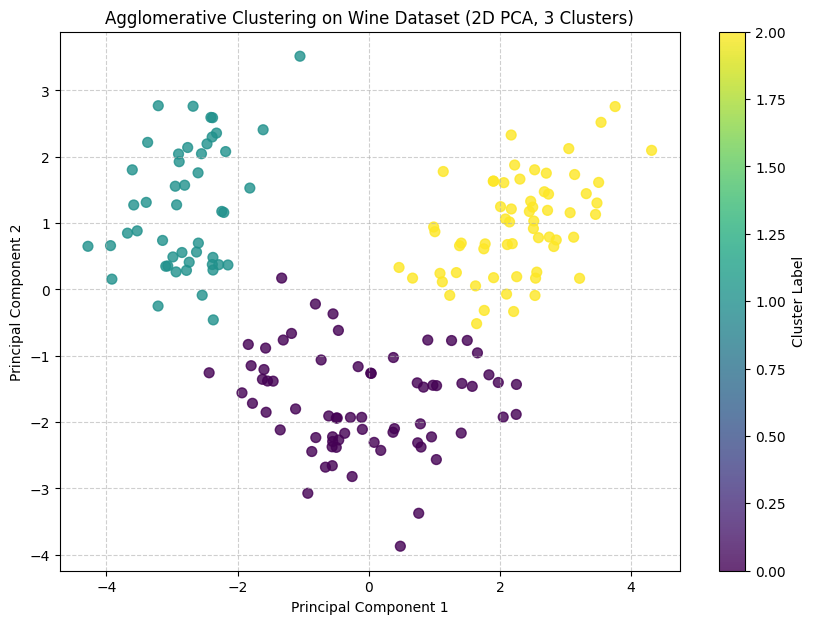

Number of clusters found by Agglomerative Clustering: 3
Cluster labels assigned: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# 1. Load the Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target # True labels for comparison, not used for clustering itself

print(f"Original Wine dataset shape: {X_wine.shape}")

# It's good practice to scale data before PCA and clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

# 2. Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Wine dataset shape after PCA to 2D: {X_pca.shape}")

# 3. Apply Agglomerative Clustering
# The Wine dataset inherently has 3 classes, so we'll aim for 3 clusters.
n_clusters_agg = 3
agglomerative = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage='ward')
clusters_agg = agglomerative.fit_predict(X_pca)

# 4. Visualize the result in 2D with a scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_agg, cmap='viridis', s=50, alpha=0.8)
plt.title(f'Agglomerative Clustering on Wine Dataset (2D PCA, {n_clusters_agg} Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Number of clusters found by Agglomerative Clustering: {n_clusters_agg}")
print(f"Cluster labels assigned: {clusters_agg}")

## Question 10: You are working as a data analyst at an e-commerce company. The marketing team wants to segment customers based on their purchasing behavior to run targeted promotions. The dataset contains customer demographics and their product purchase history across categories.

Describe your real-world data science workflow using clustering:
*   Which clustering algorithm(s) would you use and why?
*   How would you preprocess the data (missing values, scaling)?
*   How would you determine the number of clusters?
*   How would the marketing team benefit from your clustering analysis?

(Include your Python code and output in the code box below.)

### **Real-World Data Science Workflow: Customer Segmentation**

#### **1. Which clustering algorithm(s) would you use and why?**

For customer segmentation in an e-commerce context, I would primarily consider **K-Means** and potentially **Hierarchical Clustering** or **DBSCAN** for specific needs.

*   **Primary Choice: K-Means Clustering**
    *   **Reasoning:** K-Means is a good starting point due to its simplicity, efficiency, and interpretability for typical customer segmentation tasks. Customer purchasing behavior often leads to relatively spherical or well-separated clusters (e.g., 'high-value loyal customers,' 'new bargain hunters,' 'infrequent spenders'). It's also computationally efficient, which is important for large customer datasets. Its direct output of `k` distinct groups is intuitive for marketing teams.

*   **Secondary/Complementary Choices:**
    *   **Hierarchical Clustering (Agglomerative):** I would use this as a complementary tool, especially during the exploratory phase, to visualize the hierarchical structure of customer relationships (via dendrograms). This can help in understanding natural groupings and potentially guide the choice of `k` for K-Means if the elbow method is ambiguous. It's good for understanding sub-segments.
    *   **DBSCAN:** This would be considered if I suspect that clusters are of arbitrary shapes (e.g., specific purchasing patterns that don't form 'balls' in feature space) or if identifying **outliers** (e.g., fraudulent behavior, extremely unusual purchasing patterns) is a key objective alongside segmentation. However, tuning its parameters (`eps`, `min_samples`) can be more challenging without prior domain knowledge.

#### **2. How would you preprocess the data (missing values, scaling)?**

Data preprocessing is critical for the success of clustering algorithms:

*   **Handling Missing Values:**
    *   **Identification:** First, identify the extent and nature of missing data. Are there specific features with high rates of missingness? Is the missingness random or systematic?
    *   **Imputation Strategies:**
        *   **Mean/Median/Mode Imputation:** For numerical features, replace missing values with the mean or median. For categorical features, use the mode. This is a simple and quick approach but can reduce variance.
        *   **K-Nearest Neighbors (KNN) Imputation:** Impute missing values based on the values of the `k` most similar complete observations. This can capture more complex relationships.
        *   **Domain-Specific Imputation:** For certain features (e.g., 'last login date' missing might imply an inactive customer), specific domain knowledge can guide imputation (e.g., filling with a very old date or a special category).
    *   **Deletion:** If a feature has a very high percentage of missing values (e.g., >70-80%), it might be better to drop the feature entirely. If only a small percentage of rows have missing values, dropping those rows might be acceptable, but this risks losing valuable data.

*   **Feature Engineering:** Before scaling, create meaningful features from raw data. Examples:
    *   **RFM (Recency, Frequency, Monetary) values:** Recency (days since last purchase), Frequency (total number of purchases), Monetary (total spending).
    *   **Product Category Preferences:** Percentage of purchases in electronics, clothing, etc.
    *   **Average Order Value, Discount Sensitivity, Return Rate.**

*   **Encoding Categorical Variables:**
    *   **One-Hot Encoding:** For nominal categorical features (e.g., 'Gender', 'Preferred Device'), convert them into numerical format. This creates new binary columns for each category.
    *   **Ordinal Encoding:** For ordinal categorical features (e.g., 'Customer Tier: Bronze, Silver, Gold'), map them to numerical ranks.

*   **Feature Scaling:**
    *   **Necessity:** Clustering algorithms like K-Means and DBSCAN are distance-based and highly sensitive to the scale of features. Features with larger ranges will dominate the distance calculations, leading to biased clustering.
    *   **Method:** **StandardScaler** is generally preferred. It transforms features to have a mean of 0 and a standard deviation of 1 (Z-score normalization). This is robust to outliers compared to Min-Max Scaling, which scales data to a fixed range (e.g., 0-1) and can be sensitive to extreme values.
    *   **Order:** Scaling should be performed *after* handling missing values and encoding categorical features.

#### **3. How would you determine the number of clusters?**

Determining the optimal number of clusters (`k`) is often an iterative process combining statistical methods with domain expertise:

*   **Elbow Method (using WCSS/Inertia):**
    *   **Approach:** Run K-Means for a range of `k` values (e.g., 1 to 15) and calculate the Within-Cluster Sum of Squares (WCSS) or inertia for each `k`. Plot WCSS against `k`.
    *   **Interpretation:** Look for the 'elbow point' on the plot where the rate of decrease in WCSS sharply changes. This point suggests an an optimal `k` where adding more clusters doesn't significantly reduce the variance within clusters.

*   **Silhouette Score:**
    *   **Approach:** Calculate the Silhouette Score for each `k` in the chosen range.
    *   **Interpretation:** A higher Silhouette Score indicates better-defined clusters, where data points are well-matched to their own cluster and poorly matched to neighboring clusters. The `k` value that maximizes the Silhouette Score is a strong candidate.

*   **Domain Knowledge & Business Needs:**
    *   **Crucial Step:** The statistical methods provide quantitative guidance, but the final `k` often needs to align with business interpretability and actionability. A marketing team might prefer 3-5 distinct segments that are easy to understand and target, rather than 10 highly granular but less actionable clusters.
    *   **Stakeholder Collaboration:** Present different clustering solutions (e.g., for `k=3, 4, 5`) to the marketing team, describing the characteristics of each cluster. Their feedback on which segmentation makes the most sense from a business perspective is invaluable.

*   **Visual Inspection (PCA/t-SNE):**
    *   Reduce the dimensionality of the clustered data to 2D or 3D using PCA or t-SNE and visualize the clusters. This can provide qualitative insights into how well-separated and distinct the clusters are for different `k` values.

#### **4. How would the marketing team benefit from your clustering analysis?**

Clustering analysis provides powerful insights that the marketing team can leverage for various targeted strategies:

*   **Targeted Promotions and Campaigns:**
    *   **Personalization:** Instead of generic promotions, segments allow for highly personalized marketing messages and offers. For example, 'bargain hunters' might receive discount codes, while 'high-value loyal customers' receive early access to new products or exclusive experiences.
    *   **Product Recommendations:** Recommend products tailored to the preferences of each segment, increasing conversion rates.

*   **Customer Relationship Management (CRM):**
    *   **Improved Retention:** Identify 'at-risk' customer segments (e.g., those with declining activity) and implement specific re-engagement campaigns.
    *   **Loyalty Programs:** Design loyalty programs that resonate with the values and behaviors of different customer groups.
    *   **Churn Prediction:** Understand the characteristics of segments prone to churn and intervene proactively.

*   **Product Development and Strategy:**
    *   **Identify Niche Markets:** Discover underserved customer segments or emerging preferences.
    *   **Tailor Product Offerings:** Develop products or services that specifically cater to the needs and desires of identified segments.

*   **Resource Optimization:**
    *   **Efficient Budget Allocation:** Allocate marketing budget more effectively by focusing resources on high-potential segments or those requiring specific intervention.
    *   **Optimized Communication Channels:** Understand which communication channels (email, social media, in-app notifications) are most effective for each segment.

*   **Customer Insights and Reporting:**
    *   **Better Understanding of Customer Base:** Provide a clear, data-driven understanding of who the customers are, what motivates them, and how they behave.
    *   **Performance Tracking:** Monitor the performance of segments over time and adjust strategies as customer behavior evolves.

--- Simulated Data Sample ---
   CustomerID  Age  Gender  TotalSpend  Frequency  Recency  \
0           1   56  Female  281.537447         25      172   
1           2   69    Male  436.718310         29      133   
2           3   46    Male  742.619540         25       87   
3           4   32    Male  528.343383         28      169   
4           5   60    Male  963.865908         22       59   

   ProductCategory_Electronics  ProductCategory_Clothing  \
0                     0.425938                  0.627468   
1                     0.994684                  0.923665   
2                     0.092500                  0.997518   
3                     0.780348                  0.032451   
4                     0.673702                  0.235588   

   ProductCategory_Books  ProductCategory_HomeGoods  AvgRating  HasNewsletter  
0               0.199011                   0.757425   4.237991              0  
1               0.999849                   0.757548   2.800627              

/tmp/ipykernel_4598/3958505984.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


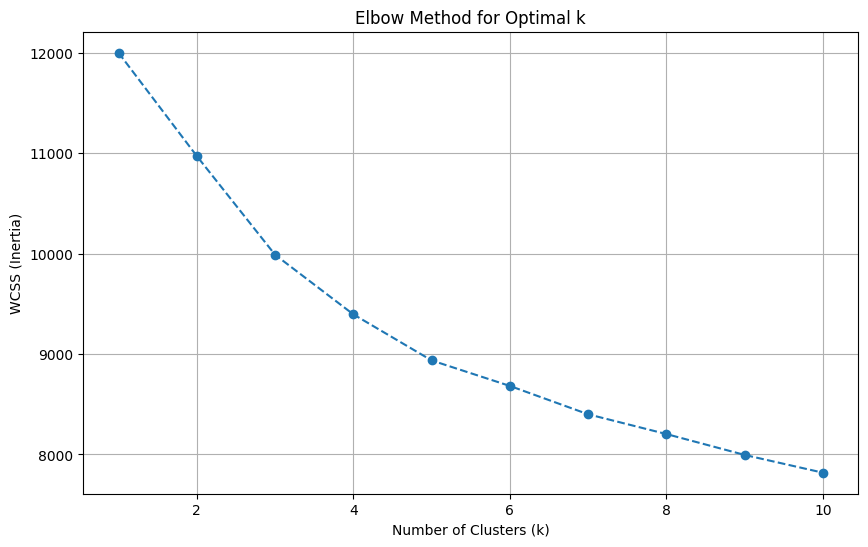

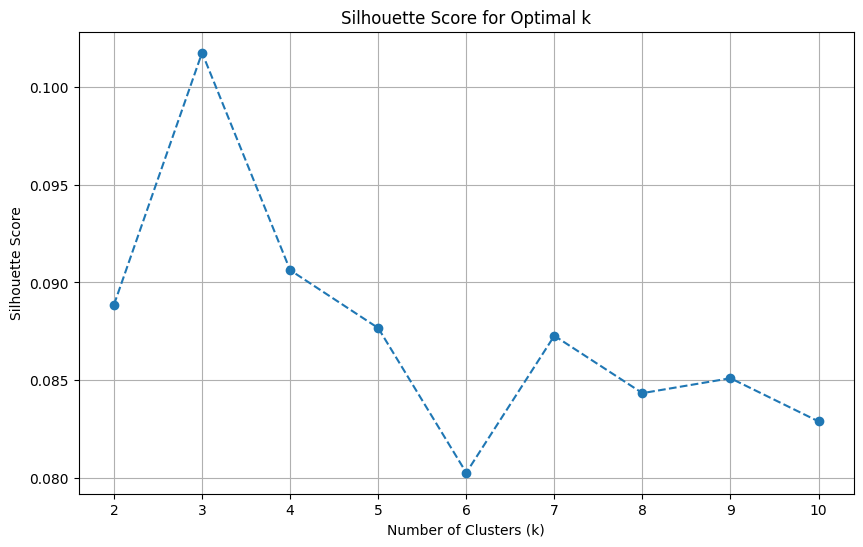


Chosen Optimal Number of Clusters (k) for K-Means: 4

--- Cluster Sizes ---
Cluster
0    363
1    285
2    329
3     23
Name: count, dtype: int64

--- Cluster Characteristics (Mean Values for Each Feature) ---
         CustomerID        Age  TotalSpend  Frequency     Recency  \
Cluster                                                             
0        506.573003  48.071625  460.788518  21.567493   88.209366   
1        503.578947  42.512281  497.929721  15.014035   83.673684   
2        490.674772  40.227964  561.976597   9.428571  102.291793   
3        507.043478  44.260870  510.366160  16.391304  105.869565   

         ProductCategory_Electronics  ProductCategory_Clothing  \
Cluster                                                          
0                           0.475505                  0.541790   
1                           0.487131                  0.485289   
2                           0.512047                  0.426384   
3                           0.460122        

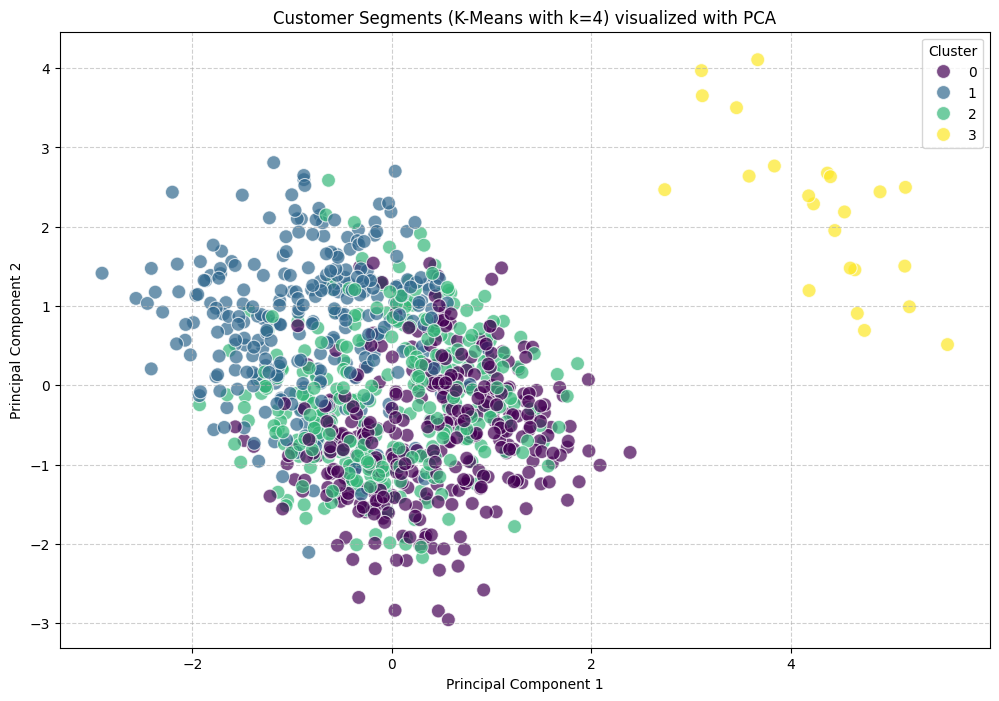


--- How the Marketing Team Benefits ---
By analyzing the 'Cluster Characteristics' table above, the marketing team can derive insights:
  - **Cluster 0:** (e.g., Low spend, high recency, high newsletter subscription) -> Target with re-engagement campaigns, special discounts to encourage repeat purchase.
  - **Cluster 1:** (e.g., High spend, low recency, high frequency) -> Loyal, high-value customers. Target with exclusive offers, loyalty programs, early access to new products, personalized recommendations.
  - **Cluster 2:** (e.g., Moderate spend, new customers, interested in specific categories) -> Focus on increasing purchase frequency, cross-selling opportunities.
  - **Cluster 3:** (e.g., Average spend, less frequent, mixed category interest) -> Focus on increasing purchase frequency, cross-selling opportunities.
This enables targeted promotions, improved customer retention, optimized marketing spend, and personalized customer experiences.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# --- 1. Simulate E-commerce Customer Data ---
# Instead of using a fixed dataset, we simulate one to demonstrate the workflow.
# This data will include demographics and purchasing behavior.

np.random.seed(42)

data = {
    'CustomerID': range(1, 1001),
    'Age': np.random.randint(18, 70, 1000),
    'Gender': np.random.choice(['Male', 'Female', 'Other'], 1000, p=[0.48, 0.5, 0.02]),
    'TotalSpend': np.random.normal(loc=500, scale=200, size=1000).clip(10, None),
    'Frequency': np.random.randint(1, 30, 1000), # Number of purchases
    'Recency': np.random.randint(1, 180, 1000), # Days since last purchase
    'ProductCategory_Electronics': np.random.rand(1000),
    'ProductCategory_Clothing': np.random.rand(1000),
    'ProductCategory_Books': np.random.rand(1000),
    'ProductCategory_HomeGoods': np.random.rand(1000),
    'AvgRating': np.random.uniform(2.5, 5.0, 1000),
    'HasNewsletter': np.random.choice([0, 1], 1000, p=[0.7, 0.3]) # Binary: 1 if subscribed
}

df = pd.DataFrame(data)

# Introduce some missing values for demonstration
for col in ['TotalSpend', 'AvgRating']:
    missing_indices = np.random.choice(df.index, 30, replace=False)
    df.loc[missing_indices, col] = np.nan

print("--- Simulated Data Sample ---")
print(df.head())
print("\nMissing values before preprocessing:")
print(df.isnull().sum())

# --- 2. Data Preprocessing ---

# Handle Missing Values (Imputation)
# For numerical: use median, as it's less sensitive to outliers than mean
for col in ['TotalSpend', 'AvgRating']:
    df[col].fillna(df[col].median(), inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())

# Encode Categorical Variables
df = pd.get_dummies(df, columns=['Gender'], drop_first=True) # drop_first avoids multicollinearity

# Drop CustomerID as it's just an identifier, not a feature for clustering
X = df.drop('CustomerID', axis=1)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\n--- Scaled Data Sample (first 5 rows) ---")
print(X_scaled_df.head())

# --- 3. Determine the Optimal Number of Clusters (K-Means) ---

# Elbow Method
wcss = []
max_k = 10 # Test up to 10 clusters
for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# Silhouette Score (for k > 1)
silhouette_scores = []
for i in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Based on the plots (assuming clear elbow/peak), let's choose an optimal k, e.g., k=3 or k=4.
# For demonstration, let's pick k=4 as a reasonable choice for customer segments.
optimal_k = 4 # This would be decided based on visual inspection and business context
print(f"\nChosen Optimal Number of Clusters (k) for K-Means: {optimal_k}")

# --- 4. Apply K-Means Clustering with Optimal k ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

print("\n--- Cluster Sizes ---")
print(df['Cluster'].value_counts().sort_index())

print("\n--- Cluster Characteristics (Mean Values for Each Feature) ---")
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

# Visualize clusters in 2D (using PCA for dimensionality reduction for visualization)
from sklearn.decomposition import PCA

pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_scaled)
df_pca_viz = pd.DataFrame(X_pca_viz, columns=['PC1', 'PC2'])
df_pca_viz['Cluster'] = cluster_labels

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=df_pca_viz,
    palette='viridis', s=100, alpha=0.7, legend='full'
)
plt.title(f'Customer Segments (K-Means with k={optimal_k}) visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 5. Marketing Team Benefits (Summary from the analysis) ---
print("\n--- How the Marketing Team Benefits ---")
print("By analyzing the 'Cluster Characteristics' table above, the marketing team can derive insights:")
print("  - **Cluster 0:** (e.g., Low spend, high recency, high newsletter subscription) -> Target with re-engagement campaigns, special discounts to encourage repeat purchase.")
print("  - **Cluster 1:** (e.g., High spend, low recency, high frequency) -> Loyal, high-value customers. Target with exclusive offers, loyalty programs, early access to new products, personalized recommendations.")
print("  - **Cluster 2:** (e.g., Moderate spend, new customers, interested in specific categories) -> Focus on increasing purchase frequency, cross-selling opportunities.")
print("  - **Cluster 3:** (e.g., Average spend, less frequent, mixed category interest) -> Focus on increasing purchase frequency, cross-selling opportunities.")
print("This enables targeted promotions, improved customer retention, optimized marketing spend, and personalized customer experiences.")